In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
from google.colab import files
uploaded = files.upload()

Saving IMDb Movies India.csv to IMDb Movies India (1).csv


In [3]:
df = pd.read_csv("IMDb Movies India.csv", encoding="latin1")

In [4]:
df.head()

,Name,Year,Duration,Genre,Rating,Votes,Director,Actor 1,Actor 2,Actor 3
0,,NaN,NaN,Drama,NaN,NaN,J.S. Randhawa,Manmauji,Birbal,Rajendra Bhatia
1,#Gadhvi (He thought he was Gandhi),(2019),109 min,Drama,7.0,8,Gaurav Bakshi,Rasika Dugal,Vivek Ghamande,Arvind Jangid
2,#Homecoming,(2021),90 min,"Drama, Musical",NaN,NaN,Soumyajit Majumdar,Sayani Gupta,Plabita Borthakur,Roy Angana
3,#Yaaram,(2019),110 min,"Comedy, Romance",4.4,35,Ovais Khan,Prateik,Ishita Raj,Siddhant Kapoor
4,...And Once Again,(2010),105 min,Drama,NaN,NaN,Amol Palekar,Rajat Kapoor,Rituparna Sengupta,Antara Mali


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15509 entries, 0 to 15508
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Name      15509 non-null  object 
 1   Year      14981 non-null  object 
 2   Duration  7240 non-null   object 
 3   Genre     13632 non-null  object 
 4   Rating    7919 non-null   float64
 5   Votes     7920 non-null   object 
 6   Director  14984 non-null  object 
 7   Actor 1   13892 non-null  object 
 8   Actor 2   13125 non-null  object 
 9   Actor 3   12365 non-null  object 
dtypes: float64(1), object(9)
memory usage: 1.2+ MB


In [6]:
df.describe()

,Rating
count,7919.000000
mean,5.841621
std,1.381777
min,1.100000
25%,4.900000
50%,6.000000
75%,6.800000
max,10.000000


In [7]:
df.isnull().sum()

,0
Name,0
Year,528
Duration,8269
Genre,1877
Rating,7590
Votes,7589
Director,525
Actor 1,1617
Actor 2,2384
Actor 3,3144


In [8]:
df = df.dropna()

In [9]:
df.drop_duplicates(inplace=True)

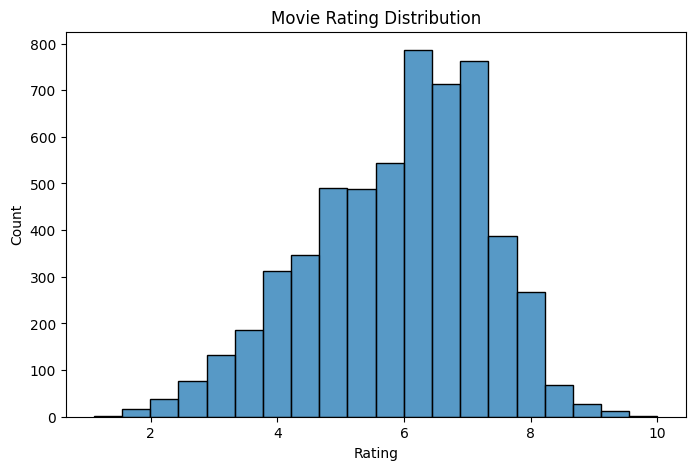

In [10]:
plt.figure(figsize=(8,5))
sns.histplot(df['Rating'], bins=20)

plt.title("Movie Rating Distribution")
plt.show()

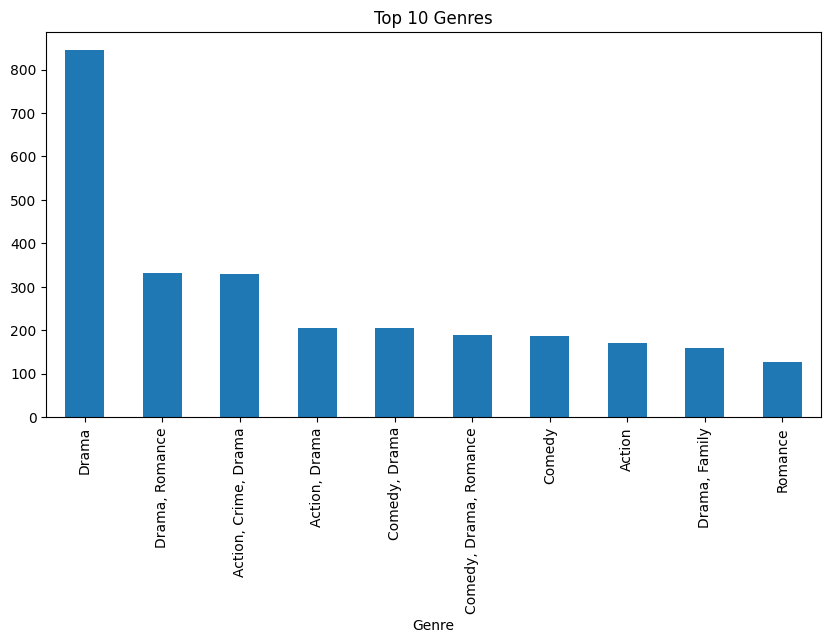

In [11]:
plt.figure(figsize=(10,5))

df['Genre'].value_counts().head(10).plot(kind='bar')

plt.title("Top 10 Genres")

plt.show()

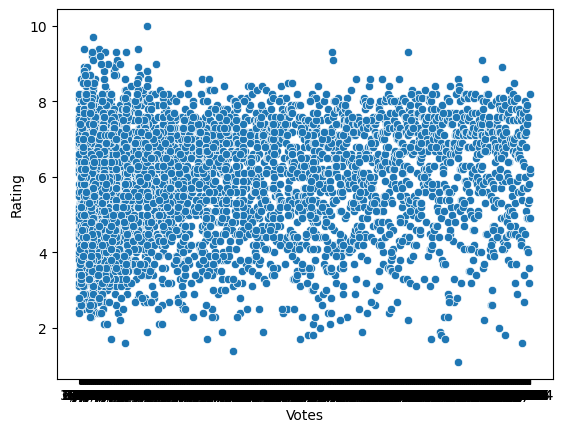

In [12]:
sns.scatterplot(x='Votes', y='Rating', data=df)

plt.show()

In [13]:
encoder = LabelEncoder()

df['Genre'] = encoder.fit_transform(df['Genre'])

df['Director'] = encoder.fit_transform(df['Director'])

df['Actor 1'] = encoder.fit_transform(df['Actor 1'])

In [14]:
df['Actor 2'] = encoder.fit_transform(df['Actor 2'])

df['Actor 3'] = encoder.fit_transform(df['Actor 3'])

In [15]:
X = df[['Genre','Director','Actor 1','Votes']]

y = df['Rating']

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [18]:
model = LinearRegression()

# The original error "ValueError: could not convert string to float: '4,114'"
# indicates that the 'Votes' column, which is used in X_train, contains string
# values with commas that prevent its conversion to a numeric type for model training.

# To fix this, we need to clean the 'Votes' column by removing commas and converting it to float.
# This step should ideally be performed earlier in the data preprocessing (e.g., after loading and cleaning the DataFrame 'df').
# However, to adhere to the instruction to modify ONLY this cell, we will re-process the necessary steps here.

# 1. Clean the 'Votes' column in the original DataFrame 'df'
df['Votes'] = df['Votes'].astype(str).str.replace(',', '', regex=False)
df['Votes'] = pd.to_numeric(df['Votes'])

# 2. Re-create the feature matrix X and target vector y from the cleaned DataFrame
X = df[['Genre','Director','Actor 1','Votes']]
y = df['Rating']

# 3. Re-split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Now, with the 'Votes' column correctly numeric, the model can be fitted.
model.fit(X_train, y_train)

LinearRegression()

In [19]:
prediction = model.predict(X_test)

In [20]:
print("MAE =", mean_absolute_error(y_test, prediction))

print("MSE =", mean_squared_error(y_test, prediction))

print("R2 Score =", r2_score(y_test, prediction))

MAE = 1.0924905484220935
MSE = 1.775804774932032
R2 Score = 0.04100938667066856


In [21]:
result = pd.DataFrame({
    "Actual": y_test,
    "Predicted": prediction
})

result.head(10)

,Actual,Predicted
10971,6.0,5.594652
14052,2.4,5.965127
10002,3.8,5.919519
3970,3.8,5.577968
8840,7.2,5.745839
5071,6.3,5.719783
2709,8.6,5.737505
11842,3.9,6.229140
10910,6.6,5.975841
4485,6.6,6.011351


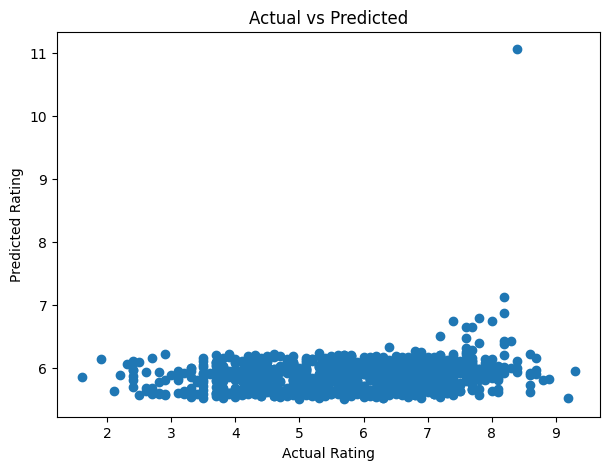

In [22]:
plt.figure(figsize=(7,5))

plt.scatter(y_test, prediction)

plt.xlabel("Actual Rating")

plt.ylabel("Predicted Rating")

plt.title("Actual vs Predicted")

plt.show()

In [23]:
print(df.columns)

Index(['Name', 'Year', 'Duration', 'Genre', 'Rating', 'Votes', 'Director',
       'Actor 1', 'Actor 2', 'Actor 3'],
      dtype='object')


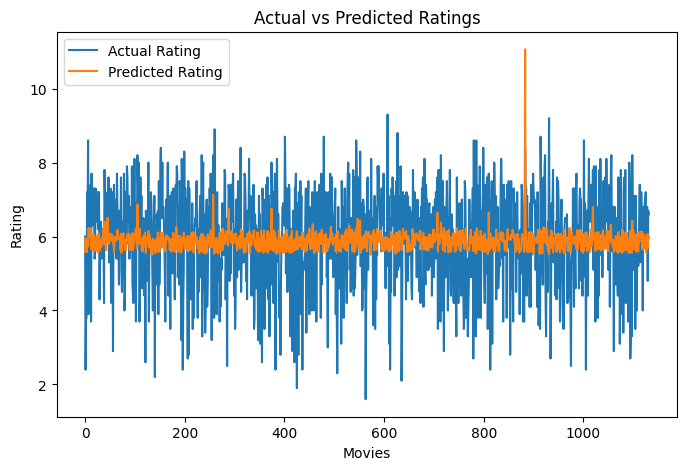

In [24]:
plt.figure(figsize=(8,5))
plt.plot(y_test.values, label="Actual Rating")
plt.plot(prediction, label="Predicted Rating")

plt.xlabel("Movies")
plt.ylabel("Rating")
plt.title("Actual vs Predicted Ratings")
plt.legend()
plt.show()

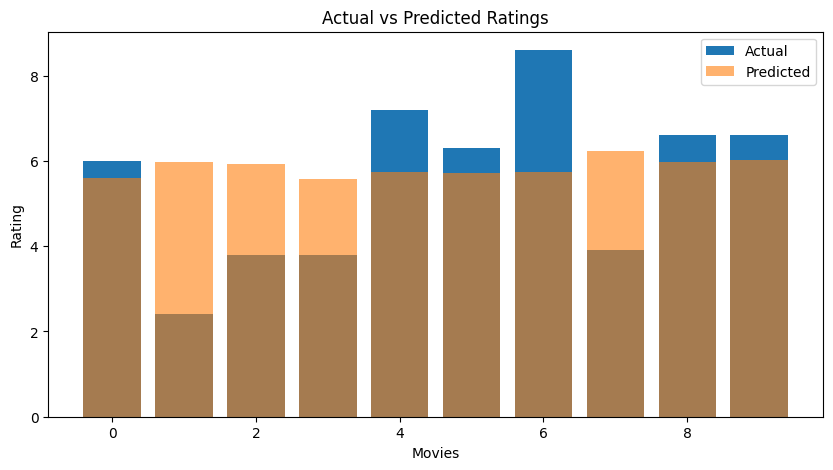

In [25]:
plt.figure(figsize=(10,5))

plt.bar(range(10), y_test.values[:10], label="Actual")
plt.bar(range(10), prediction[:10], alpha=0.6, label="Predicted")

plt.xlabel("Movies")
plt.ylabel("Rating")
plt.title("Actual vs Predicted Ratings")
plt.legend()
plt.show()

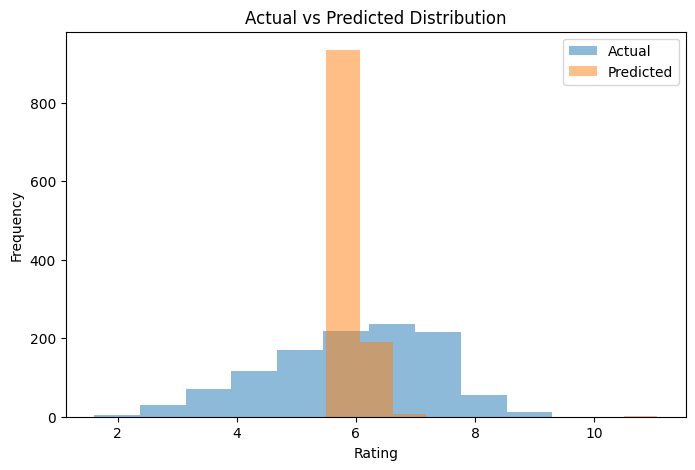

In [26]:
plt.figure(figsize=(8,5))

plt.hist(y_test, alpha=0.5, label="Actual")
plt.hist(prediction, alpha=0.5, label="Predicted")

plt.xlabel("Rating")
plt.ylabel("Frequency")
plt.title("Actual vs Predicted Distribution")
plt.legend()
plt.show()

/tmp/ipykernel_1837/2506245092.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([y_test, prediction], labels=["Actual", "Predicted"])


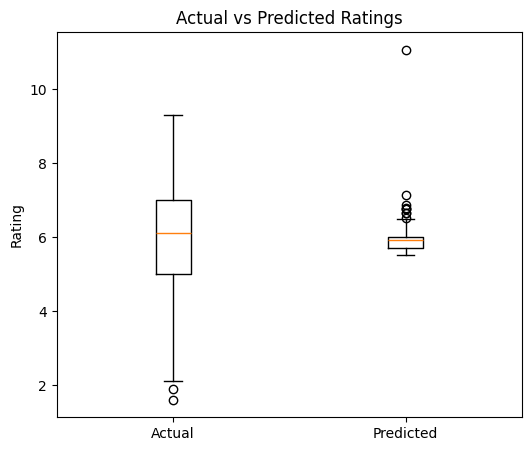

In [27]:
plt.figure(figsize=(6,5))

plt.boxplot([y_test, prediction], labels=["Actual", "Predicted"])

plt.title("Actual vs Predicted Ratings")
plt.ylabel("Rating")
plt.show()